In [1]:
# SAM 3 batch inference on a small Mars-image sample.

using_colab = True

In [2]:
if using_colab:
    import sys
    !git clone https://github.com/facebookresearch/sam3.git /content/sam3
    %cd /content/sam3
    !{sys.executable} -m pip install -e ".[notebooks]"
    !{sys.executable} -m pip install --upgrade --force-reinstall --no-cache-dir \
        "numpy==2.2.6" \
        "scipy==1.15.3" \
        "scikit-image==0.25.2" \
        "scikit-learn==1.7.2" \
        "pillow==11.3.0" \
        opencv-python matplotlib
    !hf auth login

Cloning into '/content/sam3'...
remote: Enumerating objects: 1417, done.
remote: Total 1417 (delta 0), reused 0 (delta 0), pack-reused 1417 (from 1)
Receiving objects: 100% (1417/1417), 60.46 MiB | 24.31 MiB/s, done.
Resolving deltas: 100% (550/550), done.
/content/sam3
Obtaining file:///content/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 30.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other

In [3]:
from pathlib import Path
from typing import List

import numpy as np
import torch
from PIL import Image

import sam3
from sam3 import build_sam3_image_model
from sam3.model.utils.misc import copy_data_to_device
from sam3.train.data.collator import collate_fn_api as collate
from sam3.train.data.sam3_image_dataset import (
    Datapoint,
    FindQueryLoaded,
    Image as SAMImage,
    InferenceMetadata,
)

sam3_root = Path(sam3.__file__).resolve().parent.parent
print("SAM 3 root:", sam3_root)

/content/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/content/sam3/sam3/model/model_misc.py:71: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()


SAM 3 root: /content/sam3


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [4]:
# Match the official SAM 3 batch example.
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
torch.inference_mode().__enter__()

# Utilities

## Batching

This section contains some utility functions to create datapoints. They are optional, but give some good indication on how they should be created

In [5]:
from sam3.train.data.sam3_image_dataset import InferenceMetadata, FindQueryLoaded, Image as SAMImage, Datapoint
from typing import List

GLOBAL_COUNTER = 1
def create_empty_datapoint():
    """ A datapoint is a single image on which we can apply several queries at once. """
    return Datapoint(find_queries=[], images=[])

def set_image(datapoint, pil_image):
    """ Add the image to be processed to the datapoint """
    w,h = pil_image.size
    datapoint.images = [SAMImage(data=pil_image, objects=[], size=[h,w])]

def add_text_prompt(datapoint, text_query):
    """ Add a text query to the datapoint """

    global GLOBAL_COUNTER
    # in this function, we require that the image is already set.
    # that's because we'll get its size to figure out what dimension to resize masks and boxes
    # In practice you're free to set any size you want, just edit the rest of the function
    assert len(datapoint.images) == 1, "please set the image first"

    w, h = datapoint.images[0].size
    datapoint.find_queries.append(
        FindQueryLoaded(
            query_text=text_query,
            image_id=0,
            object_ids_output=[], # unused for inference
            is_exhaustive=True, # unused for inference
            query_processing_order=0,
            inference_metadata=InferenceMetadata(
                coco_image_id=GLOBAL_COUNTER,
                original_image_id=GLOBAL_COUNTER,
                original_category_id=1,
                original_size=[w, h],
                object_id=0,
                frame_index=0,
            )
        )
    )
    GLOBAL_COUNTER += 1
    return GLOBAL_COUNTER - 1

def add_visual_prompt(datapoint, boxes:List[List[float]], labels:List[bool], text_prompt="visual"):
    """ Add a visual query to the datapoint.
    The bboxes are expected in XYXY format (top left and bottom right corners)
    For each bbox, we expect a label (true or false). The model tries to find boxes that ressemble the positive ones while avoiding the negative ones
    We can also give a text_prompt as an additional hint. It's not mandatory, leave it to "visual" if you want the model to solely rely on the boxes.

    Note that the model expects the prompt to be consistent. If the text reads "elephant" but the provided boxe points to a dog, the results will be undefined.
    """

    global GLOBAL_COUNTER
    # in this function, we require that the image is already set.
    # that's because we'll get its size to figure out what dimension to resize masks and boxes
    # In practice you're free to set any size you want, just edit the rest of the function
    assert len(datapoint.images) == 1, "please set the image first"
    assert len(boxes) > 0, "please provide at least one box"
    assert len(boxes) == len(labels), f"Expecting one label per box. Found {len(boxes)} boxes but {len(labels)} labels"
    for b in boxes:
        assert len(b) == 4, f"Boxes must have 4 coordinates, found {len(b)}"

    labels = torch.tensor(labels, dtype=torch.bool).view(-1)
    if not labels.any().item() and text_prompt=="visual":
        print("Warning: you provided no positive box, nor any text prompt. The prompt is ambiguous and the results will be undefined")
    w, h = datapoint.images[0].size
    datapoint.find_queries.append(
        FindQueryLoaded(
            query_text=text_prompt,
            image_id=0,
            object_ids_output=[], # unused for inference
            is_exhaustive=True, # unused for inference
            query_processing_order=0,
            input_bbox=torch.tensor(boxes, dtype=torch.float).view(-1,4),
            input_bbox_label=labels,
            inference_metadata=InferenceMetadata(
                coco_image_id=GLOBAL_COUNTER,
                original_image_id=GLOBAL_COUNTER,
                original_category_id=1,
                original_size=[w, h],
                object_id=0,
                frame_index=0,
            )
        )
    )
    GLOBAL_COUNTER += 1
    return GLOBAL_COUNTER - 1

# Loading

First we load our model

In [6]:
from sam3 import build_sam3_image_model

bpe_path = Path(sam3_root) / "sam3" / "assets" / "bpe_simple_vocab_16e6.txt.gz"
model = build_sam3_image_model(bpe_path=str(bpe_path))

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt: reconstructing file:   0%|          |  0.00B / 3.45GB            

sam3.pt: downloading bytes:           |  0.00B            

Then our validation transforms

In [7]:
from sam3.train.transforms.basic_for_api import (
    ComposeAPI,
    NormalizeAPI,
    RandomResizeAPI,
    ToTensorAPI,
)

transform = ComposeAPI(
    transforms=[
        RandomResizeAPI(sizes=1008, max_size=1008, square=True, consistent_transform=False),
        ToTensorAPI(),
        NormalizeAPI(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ]
)

And finally our postprocessor

In [8]:
from sam3.eval.postprocessors import PostProcessImage

postprocessor = PostProcessImage(
    max_dets_per_img=-1,
    iou_type="segm",
    use_original_sizes_box=True,
    use_original_sizes_mask=True,
    convert_mask_to_rle=False,
    detection_threshold=0.5,
    to_cpu=True,
)

# Inference

For inference, we proceed as follows:
- Create each datapoint one by one, using the functions above. Each query that we make will give us a unique id, which is then used after post-processing to retrieve the results
- Each datapoint must be transformed according to are pre-processing transforms (basically resize to 1008x1008, normalize)
- We then collate all datapoints into a batch and forward it to the model

In [20]:
# Put a small test sample in this folder before running the batch.
IMAGE_DIR = Path("/content/mars_images")
OUTPUT_JSON = Path("/content/sam3_crater_predictions.json")
PROMPT = "circle"
IMAGE_LIMIT = 2

image_paths = sorted(
    path
    for path in IMAGE_DIR.iterdir()
    if path.suffix.lower() in {".jpg", ".jpeg", ".png", ".tif", ".tiff"}
)
if IMAGE_LIMIT is not None:
    image_paths = image_paths[:IMAGE_LIMIT]
if not image_paths:
    raise FileNotFoundError(f"No images found in {IMAGE_DIR}")

print(f"Processing {len(image_paths)} images from {IMAGE_DIR}")

# Build one datapoint and one text query per image.
datapoints = []
query_ids = []
for image_path in image_paths:
    pil_image = Image.open(image_path).convert("RGB")
    datapoint = create_empty_datapoint()
    set_image(datapoint, pil_image)
    query_ids.append(add_text_prompt(datapoint, PROMPT))
    datapoints.append(transform(datapoint))

Processing 2 images from /content/mars_images


In [21]:
batch = collate(datapoints, dict_key="mars")['mars']
batch = copy_data_to_device(
    batch,
    torch.device("cuda"),
    non_blocking=True,
)
print(f"Batched {len(datapoints)} images")

Batched 2 images


In [22]:
# The first forward pass may be slow because SAM 3 compiles kernels.
# Keep inference mode local so this cell is safe to rerun independently.
with torch.inference_mode():
    output = model(batch)

In [23]:
processed_results = postprocessor.process_results(
    output,
    batch.find_metadatas,
)
print(f"Received results for {len(processed_results)} queries")

Received results for 2 queries


In [24]:
import json
from pycocotools import mask as mask_utils


def to_numpy(value):
    if hasattr(value, "detach"):
        return value.detach().float().cpu().numpy()
    return np.asarray(value)


coco = {
    "images": [],
    "annotations": [],
    "categories": [{"id": 1, "name": "crater"}],
}
annotation_id = 1

for image_id, (image_path, query_id) in enumerate(zip(image_paths, query_ids)):
    image = Image.open(image_path).convert("RGB")
    width, height = image.size
    coco["images"].append({
        "id": image_id,
        "file_name": image_path.name,
        "width": width,
        "height": height,
    })

    result = processed_results[query_id]
    masks = to_numpy(result["masks"])
    boxes = to_numpy(result["boxes"]).astype(np.float32)
    scores = to_numpy(result["scores"]).reshape(-1).astype(np.float32)
    if masks.ndim == 4 and masks.shape[1] == 1:
        masks = masks[:, 0]

    for mask, box, score in zip(masks, boxes, scores):
        mask = mask.astype(bool)
        y_indices, x_indices = np.where(mask)
        if len(x_indices) == 0:
            continue
        x_min, x_max = int(x_indices.min()), int(x_indices.max())
        y_min, y_max = int(y_indices.min()), int(y_indices.max())
        encoded = mask_utils.encode(np.asfortranarray(mask.astype(np.uint8)))
        encoded["counts"] = encoded["counts"].decode("utf-8")
        coco["annotations"].append({
            "id": annotation_id,
            "image_id": image_id,
            "category_id": 1,
            "segmentation": encoded,
            "area": int(mask.sum()),
            "bbox": [x_min, y_min, x_max - x_min + 1, y_max - y_min + 1],
            "sam3_box": [float(value) for value in box],
            "score": float(score),
            "iscrowd": 0,
        })
        annotation_id += 1

OUTPUT_JSON.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_JSON.write_text(json.dumps(coco), encoding="utf-8")
print(f"Saved {len(coco['annotations'])} annotations to {OUTPUT_JSON}")

Saved 26 annotations to /content/sam3_crater_predictions.json


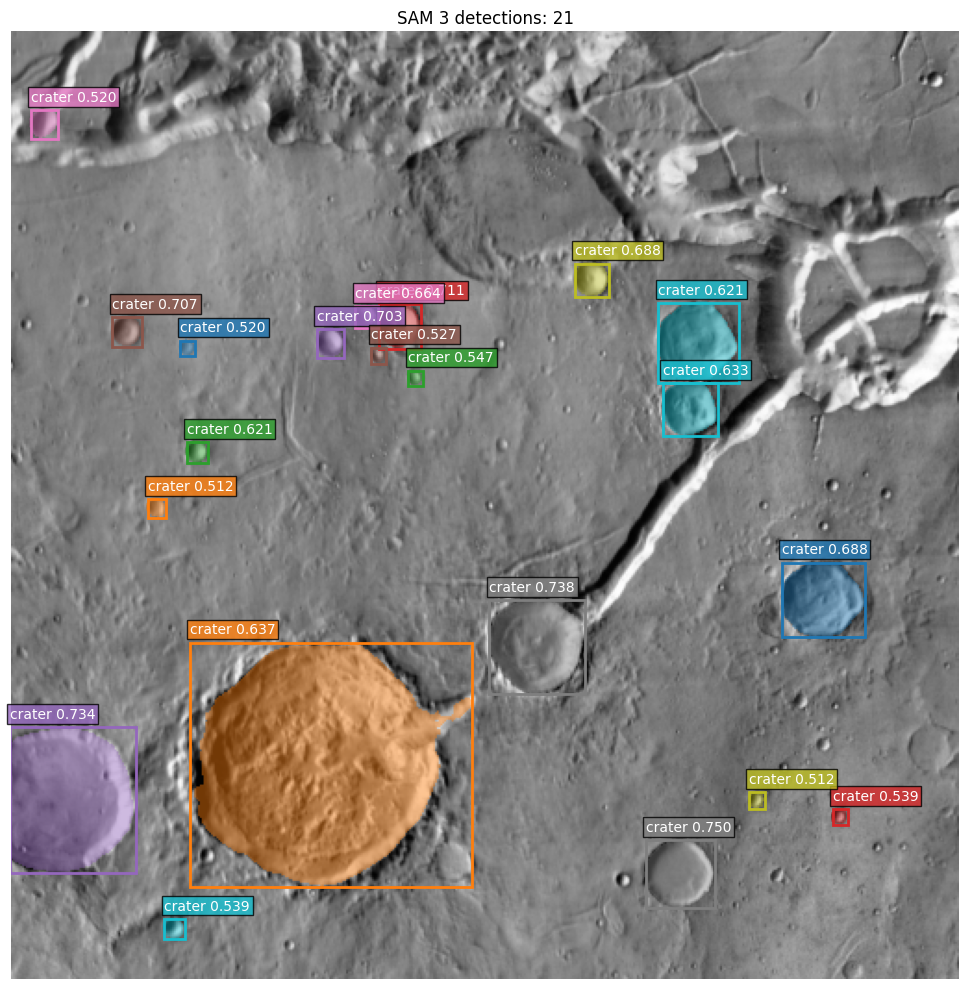

In [29]:
import matplotlib.pyplot as plt

# Preview the first processed Mars image without importing sam3.visualization_utils.
preview_image = np.asarray(Image.open(image_paths[1]).convert("RGB"))
preview_result = processed_results[query_ids[1]]
preview_masks = to_numpy(preview_result["masks"])
preview_boxes = to_numpy(preview_result["boxes"])
preview_scores = to_numpy(preview_result["scores"]).reshape(-1)

if preview_masks.ndim == 4 and preview_masks.shape[1] == 1:
    preview_masks = preview_masks[:, 0]

fig, axis = plt.subplots(figsize=(10, 10))
axis.imshow(preview_image)
colors = plt.cm.tab10(np.linspace(0, 1, max(len(preview_masks), 1)))

for mask, box, score, color in zip(
    preview_masks,
    preview_boxes,
    preview_scores,
    colors,
):
    overlay = np.zeros((*mask.shape, 4), dtype=np.float32)
    overlay[..., :3] = color[:3]
    overlay[..., 3] = mask.astype(np.float32) * 0.45
    axis.imshow(overlay)

    x_min, y_min, x_max, y_max = box
    axis.add_patch(
        plt.Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            linewidth=2,
            edgecolor=color,
            facecolor="none",
        )
    )
    axis.text(
        x_min,
        max(0, y_min - 5),
        f"crater {float(score):.3f}",
        color="white",
        bbox={"facecolor": color, "alpha": 0.8, "pad": 2},
    )

axis.set_title(f"SAM 3 detections: {len(preview_masks)}")
axis.axis("off")
fig.tight_layout()
plt.show()